In [1]:
import sys
sys.path.insert(0, '..')

import json, re
from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display

from src.metrics.alignment import TFIDFAlignment, BigramJaccardAlignment, build_corpus

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'gpqa_full_sim_tier3'

W_VALUES  = [1, 2, 5]
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
SCORE_COLORS = {'tfidf': '#4C72B0', 'jaccard': '#DD8452'}
datasets  = ['gpqa', 'hiddenbench']

/Users/I550854/Documents/Master Thesis/gdpa-benchmark/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Fit Alignment Metrics

In [2]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_qid = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = d['question_id']
        if qid not in by_qid or str(f) > by_qid[qid]['_path']:
            d['_path'] = str(f)
            by_qid[qid] = d
    return by_qid

raw = {w: load_window_data(w) for w in W_VALUES}
common_qids = sorted(set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys()))
print(f'Common qids: {len(common_qids)} — {common_qids}')

corpus = build_corpus(raw, common_qids)
print(f'Corpus size: {len(corpus)} messages')

tfidf_metric  = TFIDFAlignment()
tfidf_metric.fit(corpus)
jaccard_metric = BigramJaccardAlignment()
jaccard_metric.fit([])
print('Metrics fitted.')

Common qids: 12 — ['14', '146', '15', '159', '28', '34', '43', '46', '47', '57', '95', '98']
Corpus size: 44191 messages
Metrics fitted.


## Compute Alignment Scores

For each repetition we compute:
- `tfidf_mean` / `jaccard_mean`: mean pairwise similarity averaged over rounds (α)
- `tfidf_r0` / `jaccard_r0`: alignment at round 0 (initial state)
- `tfidf_final` / `jaccard_final`: alignment at final round
- `tfidf_delta`: how much alignment grew over the debate

In [3]:
def vote_config(votes):
    counts = sorted(Counter(votes).values(), reverse=True)
    return '-'.join(map(str, counts))

records = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids: continue
        gt      = d['ground_truth']
        dataset = d.get('dataset', 'unknown')
        for rep_idx, rep in enumerate(d['repetitions']):
            traj   = rep['trajectory']
            T      = len(traj)
            N      = len(traj[0]['phase_b'])

            r_tfidf   = tfidf_metric.score(rep)
            r_jaccard = jaccard_metric.score(rep)

            votes_r0    = [traj[0]['phase_b'][a]['vote'] for a in range(N)]
            votes_final = [traj[-1]['phase_b'][a]['vote'] for a in range(N)]
            majority_r0    = max(set(votes_r0),    key=votes_r0.count)
            majority_final = max(set(votes_final), key=votes_final.count)
            init_correct   = majority_r0    == gt
            final_correct  = majority_final == gt
            rep_converged  = len(set(votes_final)) == 1
            cfg_r0         = vote_config(votes_r0)
            n_unique_r0    = len(set(votes_r0))
            n_correct_r0   = sum(v == gt for v in votes_r0)
            debate_corrected = (not init_correct) and final_correct
            debate_corrupted = init_correct and (not final_correct)
            debate_value     = int(debate_corrected) - int(debate_corrupted)

            total_flips = sum(
                1 for a in range(N) for t in range(1, T)
                if traj[t]['phase_b'][a]['vote'] != traj[t-1]['phase_b'][a]['vote']
            )

            records.append({
                'W': w, 'qid': qid, 'dataset': dataset, 'rep': rep_idx,
                'tfidf_mean':   r_tfidf['mean'],
                'jaccard_mean': r_jaccard['mean'],
                'tfidf_r0':     r_tfidf['per_round'][0],
                'tfidf_final':  r_tfidf['per_round'][-1],
                'tfidf_delta':  r_tfidf['per_round'][-1] - r_tfidf['per_round'][0],
                'jaccard_r0':   r_jaccard['per_round'][0],
                'jaccard_final':r_jaccard['per_round'][-1],
                'jaccard_delta':r_jaccard['per_round'][-1] - r_jaccard['per_round'][0],
                'T': T, 'N': N,
                'cfg_r0': cfg_r0, 'n_unique_r0': n_unique_r0,
                'n_correct_r0': n_correct_r0,
                'init_correct': init_correct,
                'final_correct': final_correct,
                'rep_converged': rep_converged,
                'debate_corrected': debate_corrected,
                'debate_corrupted': debate_corrupted,
                'debate_value': debate_value,
                'total_flips': total_flips,
            })

df = pd.DataFrame(records)
print(f'Rows: {len(df)}  ({df["dataset"].value_counts().to_dict()})')
print(f'TF-IDF range:  [{df["tfidf_mean"].min():.3f}, {df["tfidf_mean"].max():.3f}]  mean={df["tfidf_mean"].mean():.3f}')
print(f'Jaccard range: [{df["jaccard_mean"].min():.3f}, {df["jaccard_mean"].max():.3f}]  mean={df["jaccard_mean"].mean():.3f}')
display(df.head(8))

Rows: 1800  ({'hiddenbench': 1050, 'gpqa': 750})
TF-IDF range:  [0.224, 0.645]  mean=0.408
Jaccard range: [0.067, 0.529]  mean=0.208


,W,qid,dataset,rep,tfidf_mean,jaccard_mean,tfidf_r0,tfidf_final,tfidf_delta,jaccard_r0,...,cfg_r0,n_unique_r0,n_correct_r0,init_correct,final_correct,rep_converged,debate_corrected,debate_corrupted,debate_value,total_flips
0,1,98,gpqa,0,0.436915,0.242913,0.526172,0.574119,0.047947,0.321037,...,3-1,2,0,False,False,True,False,False,0,1
1,1,98,gpqa,1,0.385971,0.206101,0.315380,0.423259,0.107880,0.152627,...,2-1-1,3,0,False,False,True,False,False,0,2
2,1,98,gpqa,2,0.378394,0.186260,0.381392,0.393498,0.012106,0.199069,...,2-1-1,3,0,False,False,True,False,False,0,2
3,1,98,gpqa,3,0.577762,0.320564,0.426989,0.686412,0.259422,0.212710,...,2-2,2,0,False,False,True,False,False,0,10
4,1,98,gpqa,4,0.512726,0.307058,0.221383,0.600687,0.379304,0.078255,...,2-1-1,3,1,False,True,True,True,False,1,5
5,1,98,gpqa,5,0.510054,0.279198,0.469953,0.689149,0.219196,0.256023,...,2-1-1,3,2,True,True,True,False,False,0,4
6,1,98,gpqa,6,0.493527,0.289805,0.462207,0.650620,0.188413,0.286193,...,3-1,2,1,False,False,True,False,False,0,3
7,1,98,gpqa,7,0.395493,0.170229,0.210235,0.504557,0.294322,0.074086,...,3-1,2,0,False,False,True,False,False,0,1


---
# Part 1 — Score Distributions

How are TF-IDF cosine alignment and bigram Jaccard alignment distributed
across repetitions? We look by dataset and by W.

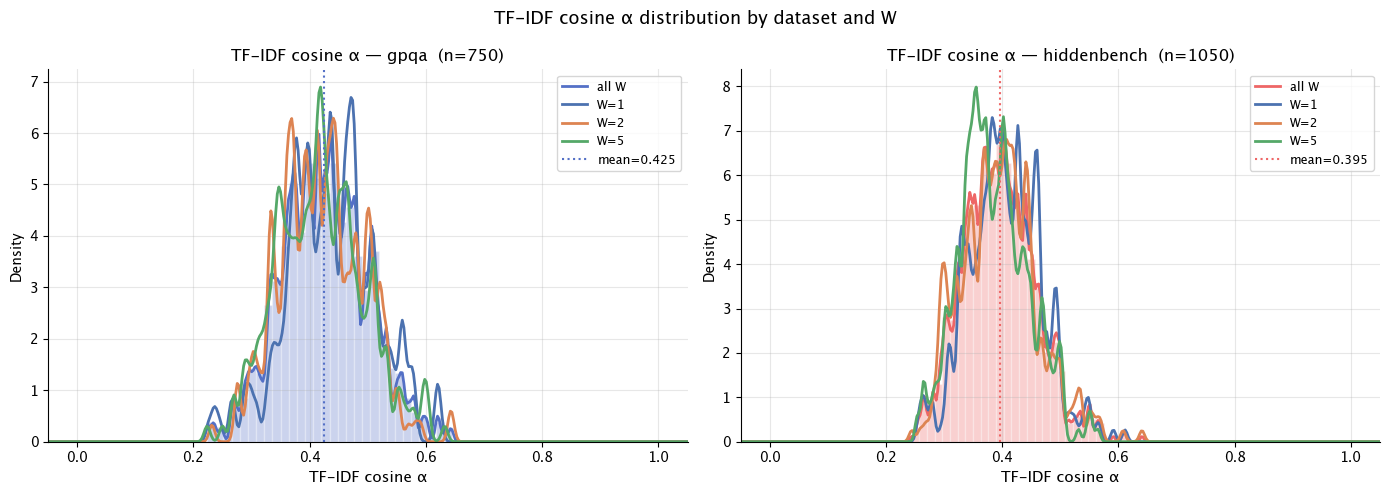

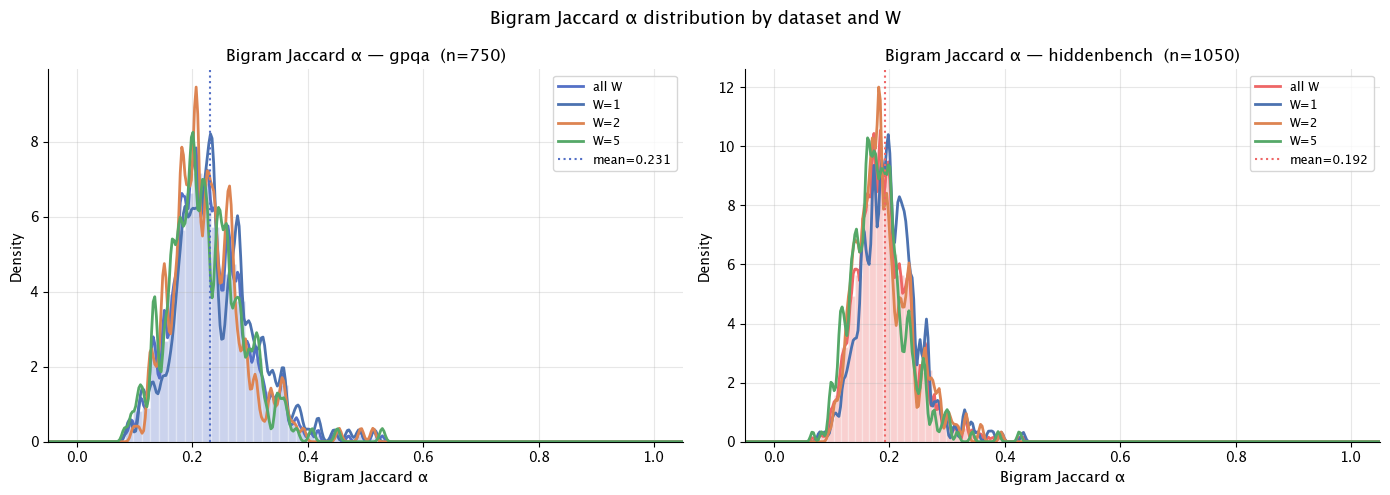

Descriptive stats by dataset × W:


tfidf_mean               jaccard_mean              
                    mean median    std         mean median    std
dataset     W                                                    
gpqa        1      0.436  0.436  0.076        0.243  0.232  0.071
            2      0.421  0.416  0.071        0.226  0.219  0.063
            5      0.419  0.417  0.075        0.223  0.217  0.065
hiddenbench 1      0.405  0.402  0.061        0.202  0.198  0.050
            2      0.396  0.393  0.065        0.191  0.183  0.049
            5      0.385  0.380  0.058        0.182  0.178  0.047

In [4]:
def kde_line(ax, vals, color, label=None, bw=0.05):
    vals = vals[np.isfinite(vals)]
    if len(vals) < 5: return
    kde = gaussian_kde(vals, bw_method=bw)
    xs = np.linspace(-0.05, 1.05, 400)
    ax.plot(xs, kde(xs), color=color, linewidth=2, label=label)

for score_col, score_label in [('tfidf_mean','TF-IDF cosine α'), ('jaccard_mean','Bigram Jaccard α')]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ds in zip(axes, datasets):
        sub = df[df['dataset']==ds]
        ax.hist(sub[score_col], bins=30, density=True,
                color=DS_COLORS[ds], alpha=0.3, edgecolor='white')
        kde_line(ax, sub[score_col].values, DS_COLORS[ds], label='all W')
        for w in W_VALUES:
            kde_line(ax, sub[sub['W']==w][score_col].values, W_COLORS[w],
                     label=f'W={w}', bw=0.07)
        ax.axvline(sub[score_col].mean(), color=DS_COLORS[ds], linewidth=1.5,
                   linestyle=':', label=f'mean={sub[score_col].mean():.3f}')
        ax.set_xlabel(score_label, fontsize=11)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{score_label} — {ds}  (n={len(sub)})', fontsize=12)
        ax.legend(fontsize=9); ax.set_xlim(-0.05, 1.05)
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.suptitle(f'{score_label} distribution by dataset and W', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Descriptive stats by dataset × W:')
display(
    df.groupby(['dataset','W'])[['tfidf_mean','jaccard_mean']]
    .agg(['mean','median','std']).round(3)
)

### Per-question distribution

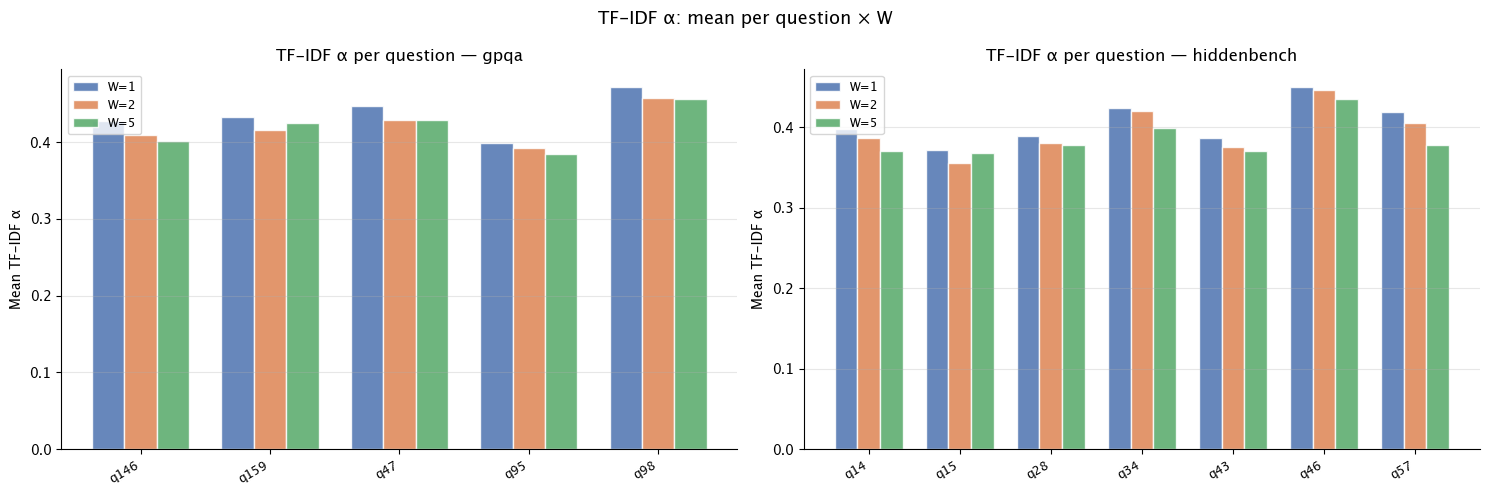

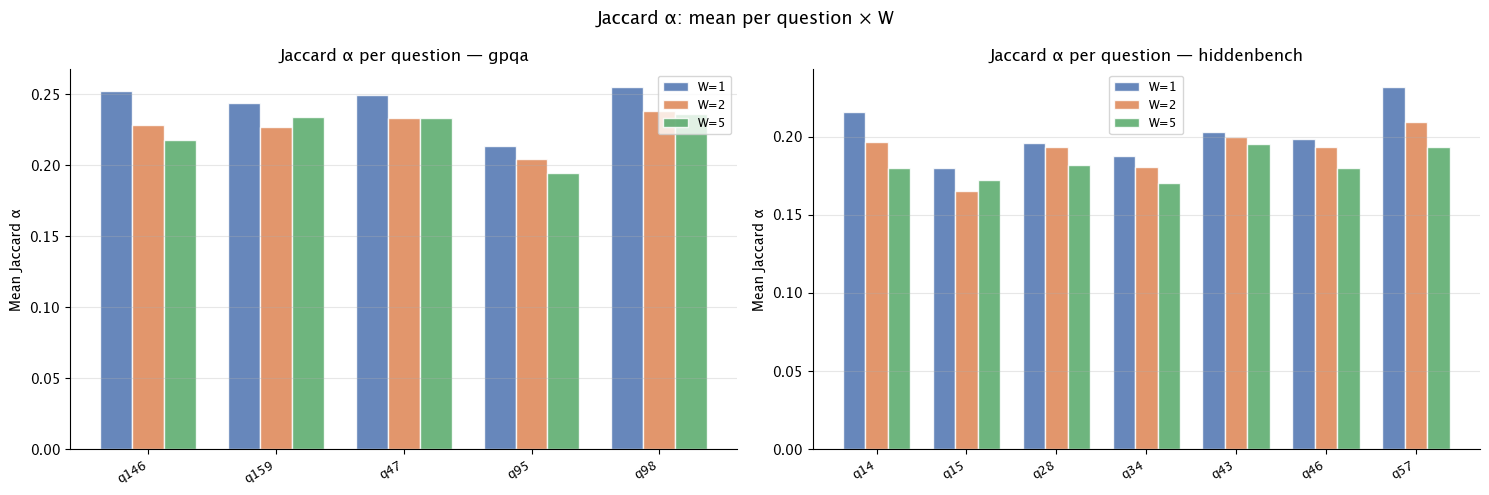

In [5]:
qdf = df.groupby(['dataset','qid','W'])[['tfidf_mean','jaccard_mean']].mean().reset_index()

for score_col, score_label in [('tfidf_mean','TF-IDF α'), ('jaccard_mean','Jaccard α')]:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, ds in zip(axes, datasets):
        sub  = qdf[qdf['dataset']==ds]
        qids = sorted(sub['qid'].unique())
        x    = np.arange(len(qids))
        for i, w in enumerate(W_VALUES):
            vals = [sub[(sub['qid']==q)&(sub['W']==w)][score_col].values[0]
                    if len(sub[(sub['qid']==q)&(sub['W']==w)]) > 0 else np.nan
                    for q in qids]
            ax.bar(x+(i-1)*0.25, vals, 0.25, color=W_COLORS[w], alpha=0.85,
                   edgecolor='white', label=f'W={w}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'q{q}' for q in qids], rotation=30, ha='right', fontsize=9)
        ax.set_ylabel(f'Mean {score_label}', fontsize=10)
        ax.set_title(f'{score_label} per question — {ds}', fontsize=12)
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.suptitle(f'{score_label}: mean per question × W', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

---
# Part 2 — Alignment Trajectory over Rounds

Does alignment grow over the course of a debate? Does W affect how fast it grows?
We also compare vote convergence vs message alignment — two distinct signals.

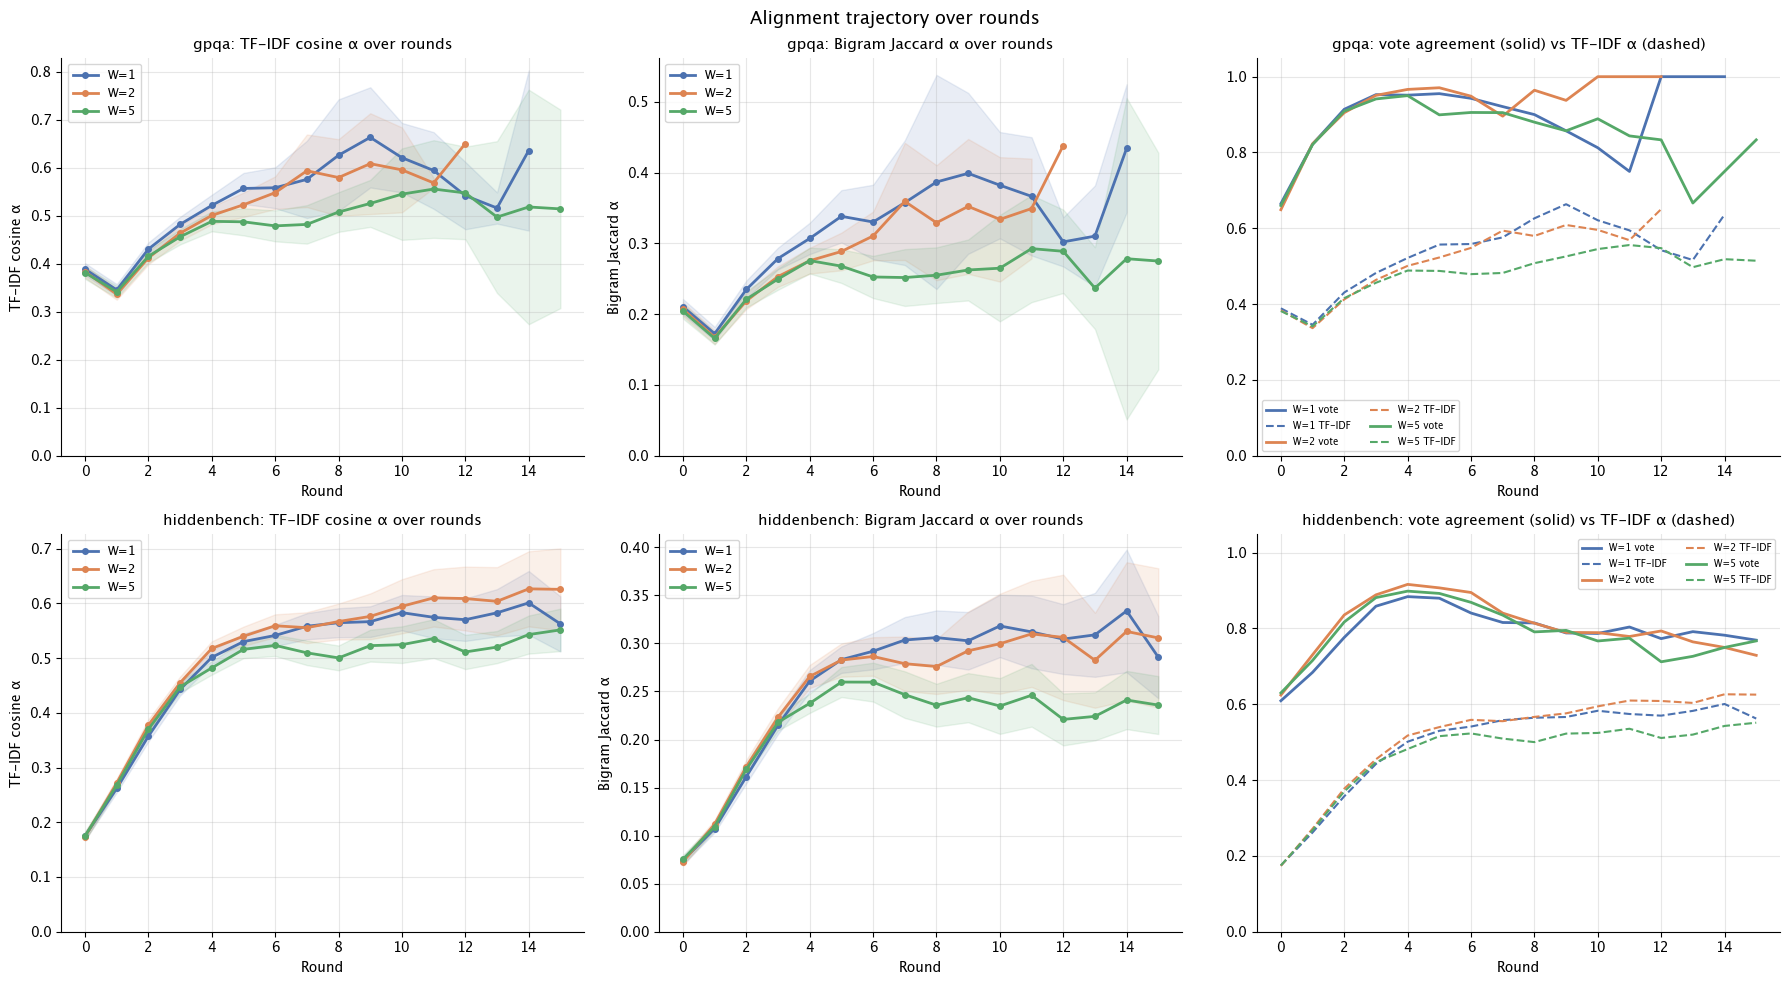

In [6]:
traj_records = []
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids: continue
        gt = d['ground_truth']
        for rep_idx, rep in enumerate(d['repetitions']):
            traj   = rep['trajectory']
            T      = len(traj)
            N      = len(traj[0]['phase_b'])
            r_tfidf   = tfidf_metric.score(rep)
            r_jaccard = jaccard_metric.score(rep)
            for t in range(T):
                votes = [traj[t]['phase_b'][a]['vote'] for a in range(N)]
                vote_agree = max(votes.count(v) for v in set(votes)) / N
                majority   = max(set(votes), key=votes.count)
                traj_records.append({
                    'W': w, 'qid': qid, 'dataset': d.get('dataset','unknown'),
                    'rep': rep_idx, 'round': t, 'T': T,
                    'tfidf':    r_tfidf['per_round'][t],
                    'jaccard':  r_jaccard['per_round'][t],
                    'vote_agree': vote_agree,
                    'correct': majority == gt,
                })

tdf = pd.DataFrame(traj_records)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub = tdf[tdf['dataset']==ds]

    for ax, col, label in [
        (axes[row,0], 'tfidf',   'TF-IDF cosine α'),
        (axes[row,1], 'jaccard', 'Bigram Jaccard α'),
    ]:
        for w in W_VALUES:
            subw = sub[sub['W']==w].groupby('round')[col]
            means, sems = subw.mean(), subw.sem()
            ax.plot(means.index, means, marker='o', markersize=4,
                    color=W_COLORS[w], label=f'W={w}', linewidth=2)
            ax.fill_between(means.index, means-sems*1.96, means+sems*1.96,
                            color=W_COLORS[w], alpha=0.12)
        ax.set_xlabel('Round', fontsize=10); ax.set_ylabel(label, fontsize=10)
        ax.set_title(f'{ds}: {label} over rounds', fontsize=11)
        ax.set_ylim(0, None); ax.legend(fontsize=9)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for w in W_VALUES:
        subw = sub[sub['W']==w].groupby('round')
        vote  = subw['vote_agree'].mean()
        tfidf = subw['tfidf'].mean()
        ax.plot(vote.index, vote,  linestyle='-',  color=W_COLORS[w], linewidth=2, label=f'W={w} vote')
        ax.plot(tfidf.index, tfidf, linestyle='--', color=W_COLORS[w], linewidth=1.5, label=f'W={w} TF-IDF')
    ax.set_xlabel('Round', fontsize=10)
    ax.set_title(f'{ds}: vote agreement (solid) vs TF-IDF α (dashed)', fontsize=11)
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7, ncol=2)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Alignment trajectory over rounds', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part 3 — What Does High Alignment Mean for System Outcome?

Same cornerstones as the persuasiveness analysis:
1. Does high alignment predict correctness?
2. Does it predict convergence?
3. High vs low alignment split — accuracy, convergence, debate length.
4. Alignment delta (how much it grew) vs outcome.

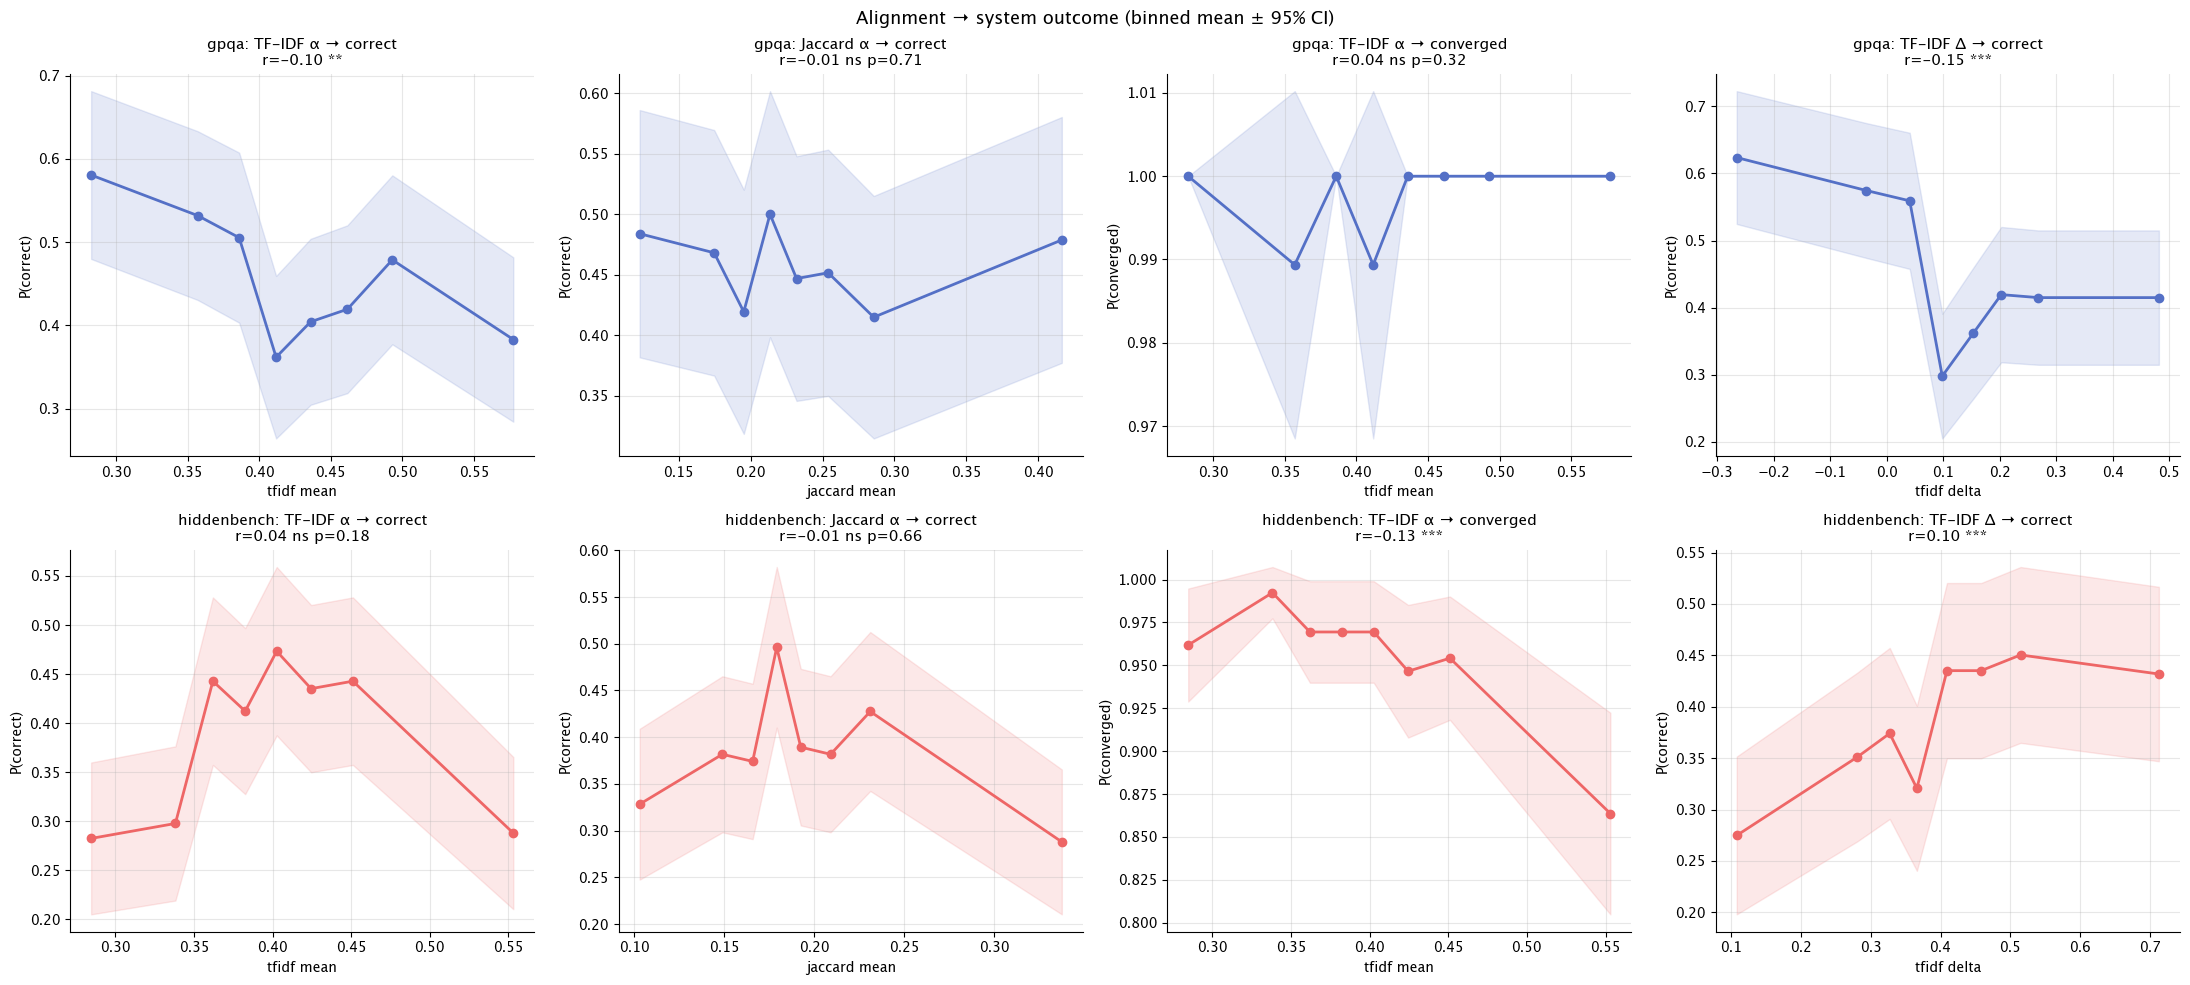

In [7]:
def binned(ax, sub, xcol, ycol, color, n_bins=8, ylabel='', title='', hline=None):
    bins = np.percentile(sub[xcol], np.linspace(0,100,n_bins+1))
    bins = np.unique(bins)
    if len(bins) < 3: return
    lbls = (bins[:-1]+bins[1:])/2
    cut  = pd.cut(sub[xcol], bins=bins, labels=lbls)
    grp  = sub.groupby(cut, observed=False)[ycol]
    means, sems, ns = grp.mean(), grp.sem(), grp.count()
    valid = ns >= 3
    xs = means.index.astype(float)[valid]
    ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=6)
    ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=color, alpha=0.15)
    r, p = sp_stats.spearmanr(sub[xcol], sub[ycol])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'ns p={p:.2f}'
    if hline is not None:
        ax.axhline(hline, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel(xcol.replace('_',' '), fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'{title}\nr={r:.2f} {sig}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for row, ds in enumerate(datasets):
    sub = df[df['dataset']==ds]
    c   = DS_COLORS[ds]
    binned(axes[row,0], sub, 'tfidf_mean',   'final_correct', c, ylabel='P(correct)',   title=f'{ds}: TF-IDF α → correct')
    binned(axes[row,1], sub, 'jaccard_mean', 'final_correct', c, ylabel='P(correct)',   title=f'{ds}: Jaccard α → correct')
    binned(axes[row,2], sub, 'tfidf_mean',   'rep_converged', c, ylabel='P(converged)', title=f'{ds}: TF-IDF α → converged')
    binned(axes[row,3], sub, 'tfidf_delta',  'final_correct', c, ylabel='P(correct)',   title=f'{ds}: TF-IDF Δ → correct')
fig.suptitle('Alignment → system outcome (binned mean ± 95% CI)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

/Users/I550854/Documents/Master Thesis/gdpa-benchmark/.venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


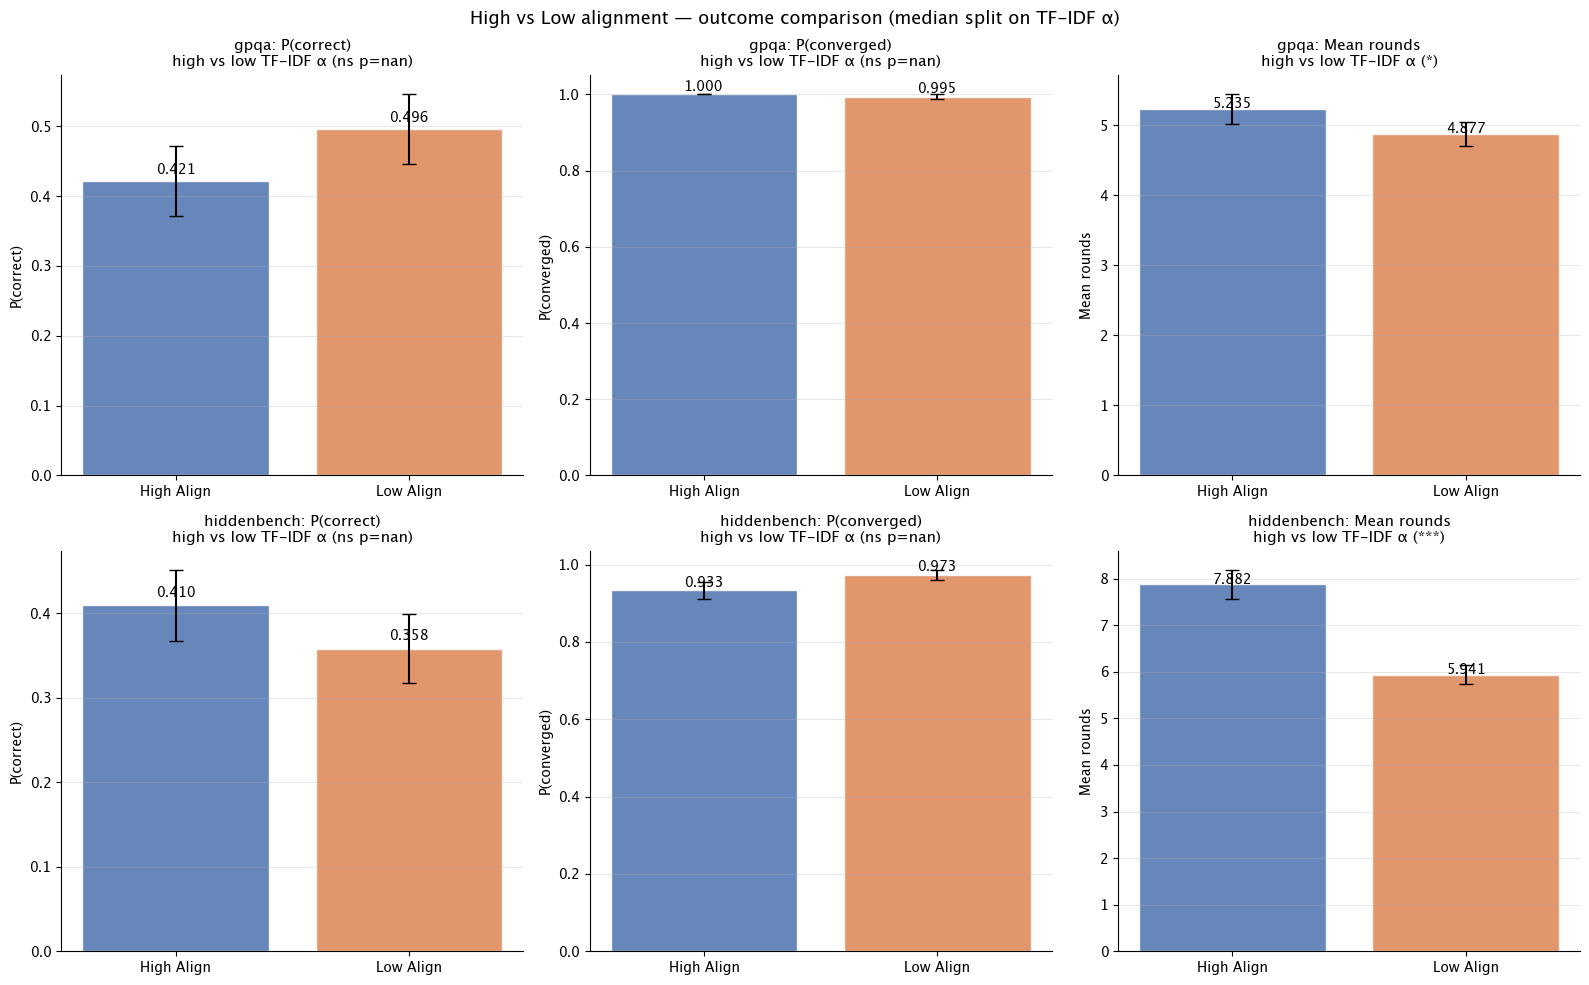

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for row, ds in enumerate(datasets):
    sub = df[df['dataset']==ds].copy()
    med = sub['tfidf_mean'].median()
    sub['align_group'] = (sub['tfidf_mean']>med).map({True:'High Align', False:'Low Align'})
    for col_idx, (metric, ylabel) in enumerate([('final_correct','P(correct)'),('rep_converged','P(converged)'),('T','Mean rounds')]):
        ax = axes[row, col_idx]
        for grp, color in [('High Align','#4C72B0'),('Low Align','#DD8452')]:
            vals = sub[sub['align_group']==grp][metric]
            ax.bar(grp, vals.mean(), color=color, alpha=0.85, edgecolor='white')
            ax.errorbar(grp, vals.mean(), yerr=vals.sem()*1.96, fmt='none', color='black', capsize=5)
            ax.text(grp, vals.mean()+0.01, f'{vals.mean():.3f}', ha='center', fontsize=10, fontweight='bold')
        t, p = sp_stats.ttest_ind(
            sub[sub['align_group']=='High Align'][metric],
            sub[sub['align_group']=='Low Align'][metric]
        )
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else f'ns p={p:.2f}'
        ax.set_title(f'{ds}: {ylabel}\nhigh vs low TF-IDF α ({sig})', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('High vs Low alignment — outcome comparison (median split on TF-IDF α)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part 4 — Confound Analysis

Alignment naturally grows over rounds just by agents reading each other's messages.
Key confounds:
1. **Debate length T** — longer debates = more rounds = more alignment, trivially.
2. **Question difficulty** — hard questions produce longer debates and possibly more divergent messages.

We test within-question partial effects and stratify by T.

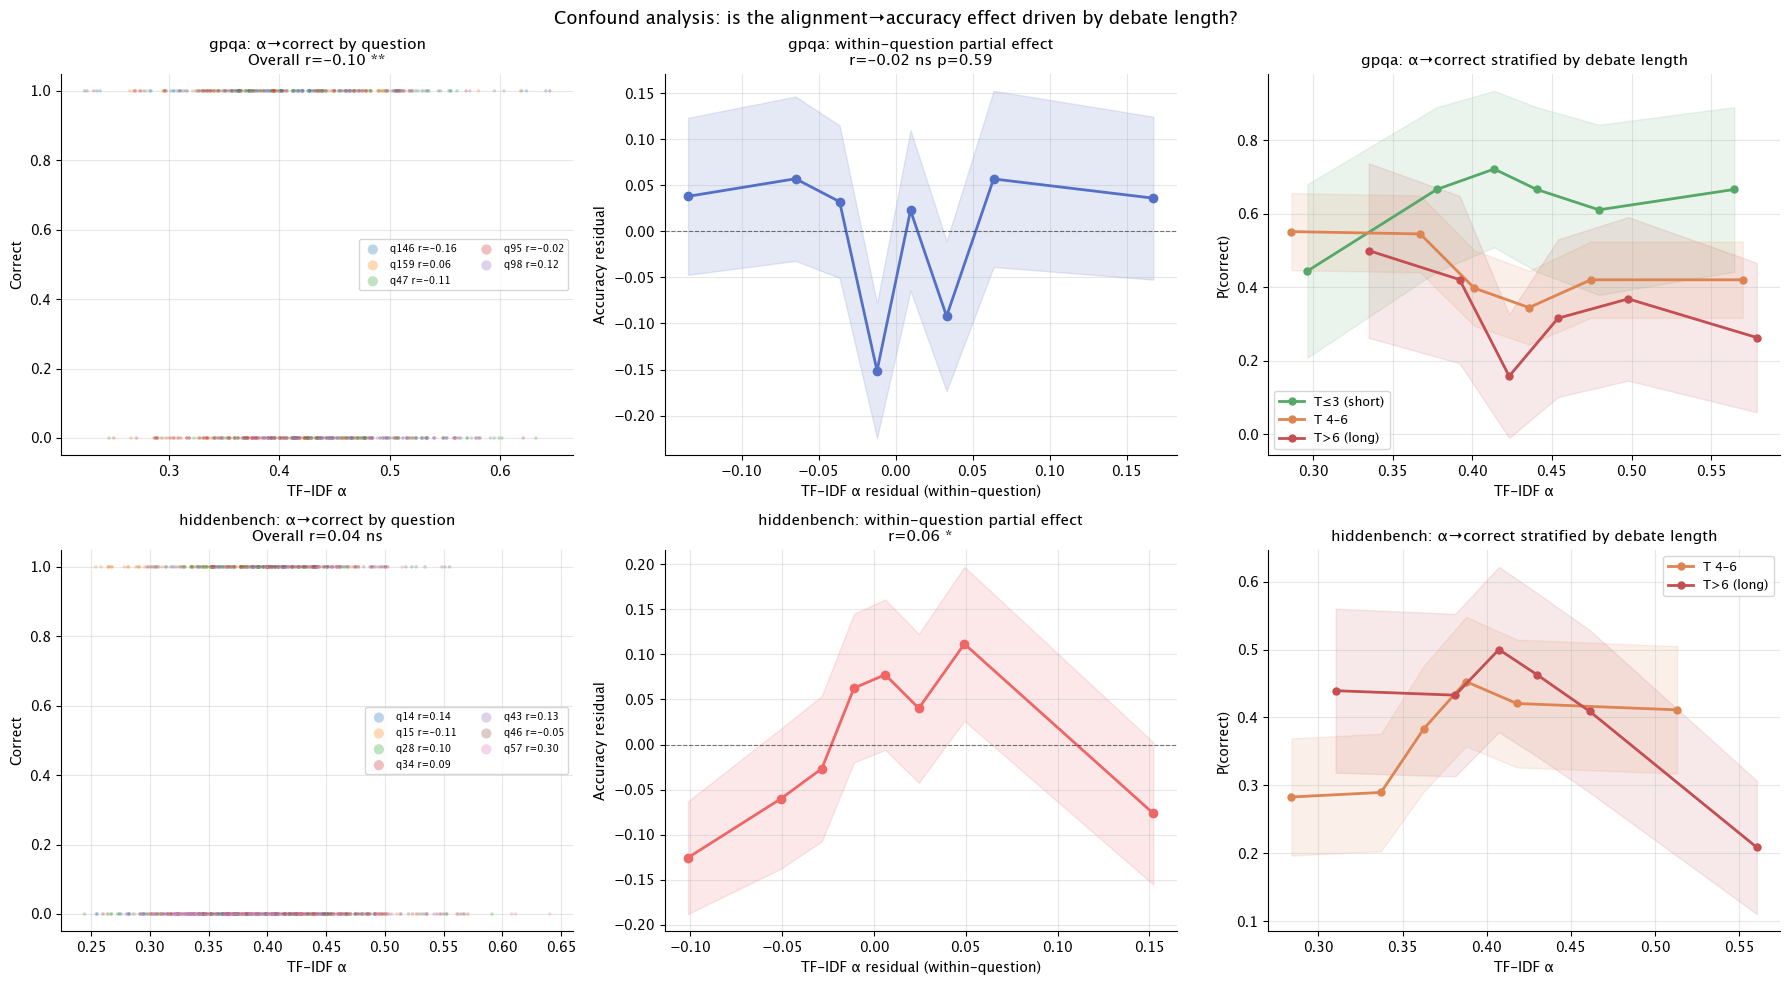

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub   = df[df['dataset']==ds].copy()
    color = DS_COLORS[ds]
    qids  = sorted(sub['qid'].unique())
    cmap  = plt.cm.tab10

    ax = axes[row, 0]
    for i, qid in enumerate(qids):
        sq = sub[sub['qid']==qid]
        r_q, _ = sp_stats.spearmanr(sq['tfidf_mean'], sq['final_correct'])
        ax.scatter(sq['tfidf_mean'], sq['final_correct'].astype(float),
                   color=cmap(i%10), s=6, alpha=0.3, edgecolors='none',
                   label=f'q{qid} r={r_q:.2f}')
    r_all, p_all = sp_stats.spearmanr(sub['tfidf_mean'], sub['final_correct'])
    sig = '***' if p_all<0.001 else '**' if p_all<0.01 else '*' if p_all<0.05 else 'ns'
    ax.set_xlabel('TF-IDF α', fontsize=10); ax.set_ylabel('Correct', fontsize=10)
    ax.set_title(f'{ds}: α→correct by question\nOverall r={r_all:.2f} {sig}', fontsize=11)
    ax.legend(fontsize=7, markerscale=3, ncol=2)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    sub2 = sub.copy()
    sub2['align_resid']   = sub2['tfidf_mean'] - sub2.groupby('qid')['tfidf_mean'].transform('mean')
    sub2['correct_resid'] = sub2['final_correct'].astype(float) - sub2.groupby('qid')['final_correct'].transform('mean')
    bins = np.percentile(sub2['align_resid'], np.linspace(0,100,9))
    bins = np.unique(bins)
    if len(bins) >= 3:
        lbls = (bins[:-1]+bins[1:])/2
        cut  = pd.cut(sub2['align_resid'], bins=bins, labels=lbls)
        grp  = sub2.groupby(cut, observed=False)['correct_resid']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 3
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=color, linewidth=2, markersize=6)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=color, alpha=0.15)
    r2, p2 = sp_stats.spearmanr(sub2['align_resid'], sub2['correct_resid'])
    sig2 = '***' if p2<0.001 else '**' if p2<0.01 else '*' if p2<0.05 else f'ns p={p2:.2f}'
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('TF-IDF α residual (within-question)', fontsize=10)
    ax.set_ylabel('Accuracy residual', fontsize=10)
    ax.set_title(f'{ds}: within-question partial effect\nr={r2:.2f} {sig2}', fontsize=11)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for t_mask, t_color, t_label in [
        (sub['T']<=3,              '#55A868','T≤3 (short)'),
        ((sub['T']>3)&(sub['T']<=6),'#DD8452','T 4–6'),
        (sub['T']>6,               '#C44E52','T>6 (long)'),
    ]:
        subT = sub[t_mask]
        if len(subT) < 10: continue
        bins = np.percentile(subT['tfidf_mean'], np.linspace(0,100,7))
        bins = np.unique(bins)
        if len(bins) < 3: continue
        lbls = (bins[:-1]+bins[1:])/2
        cut  = pd.cut(subT['tfidf_mean'], bins=bins, labels=lbls)
        grp  = subT.groupby(cut, observed=False)['final_correct']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 3
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=t_color, linewidth=2, markersize=5, label=t_label)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid], color=t_color, alpha=0.12)
    ax.set_xlabel('TF-IDF α', fontsize=10); ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: α→correct stratified by debate length', fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Confound analysis: is the alignment→accuracy effect driven by debate length?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part 5 — Alignment by Starting Vote Configuration

Does the starting vote split affect how much alignment develops?
A 3-1 split should produce rapid convergence and high alignment.
A 2-2 split means two competing factions — lower alignment expected.

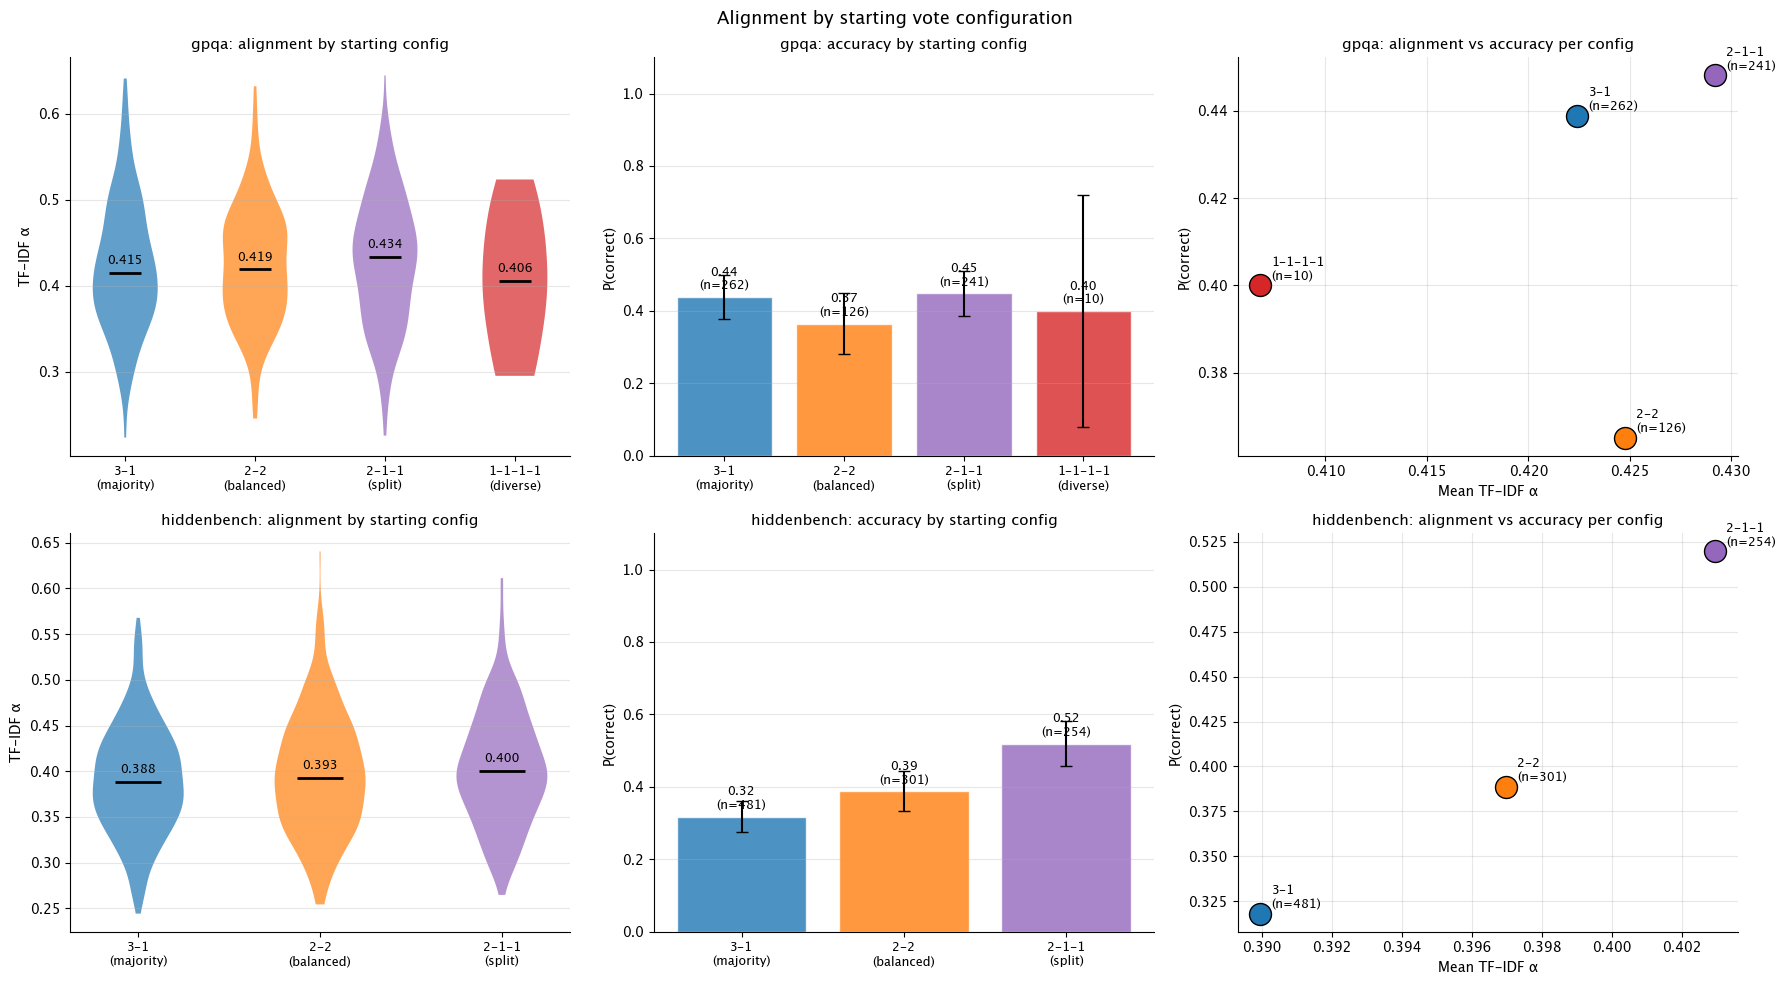

In [10]:
config_order  = ['3-1','2-2','2-1-1','1-1-1-1']
config_colors = {'4-0':'#2ca02c','3-1':'#1f77b4','2-2':'#ff7f0e','2-1-1':'#9467bd','1-1-1-1':'#d62728'}
config_labels = {
    '3-1':   '3-1\n(majority)', '2-2': '2-2\n(balanced)',
    '2-1-1': '2-1-1\n(split)',  '1-1-1-1': '1-1-1-1\n(diverse)',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub     = df[df['dataset']==ds]
    present = [c for c in config_order if c in sub['cfg_r0'].values]

    ax = axes[row, 0]
    data_by_cfg = [sub[sub['cfg_r0']==c]['tfidf_mean'].dropna().values for c in present]
    parts = ax.violinplot(data_by_cfg, positions=range(len(present)),
                          showmedians=True, showextrema=False)
    for pc, c in zip(parts['bodies'], present):
        pc.set_facecolor(config_colors.get(c,'gray')); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    for i, (c, vals) in enumerate(zip(present, data_by_cfg)):
        ax.text(i, np.median(vals)+0.01, f'{np.median(vals):.3f}',
                ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels([config_labels.get(c,c) for c in present], fontsize=9)
    ax.set_ylabel('TF-IDF α', fontsize=10)
    ax.set_title(f'{ds}: alignment by starting config', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    cfg_acc = sub.groupby('cfg_r0')['final_correct'].agg(['mean','sem','count']).reindex(present)
    ax.bar(range(len(present)), cfg_acc['mean'],
           color=[config_colors.get(c,'gray') for c in present], alpha=0.8, edgecolor='white')
    ax.errorbar(range(len(present)), cfg_acc['mean'], yerr=cfg_acc['sem']*1.96,
                fmt='none', color='black', capsize=4)
    for i, (acc, n) in enumerate(zip(cfg_acc['mean'], cfg_acc['count'])):
        ax.text(i, acc+0.02, f'{acc:.2f}\n(n={n:.0f})', ha='center', fontsize=9)
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels([config_labels.get(c,c) for c in present], fontsize=9)
    ax.set_ylabel('P(correct)', fontsize=10); ax.set_ylim(0, 1.1)
    ax.set_title(f'{ds}: accuracy by starting config', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for c in present:
        a_val = sub[sub['cfg_r0']==c]['tfidf_mean'].mean()
        acc   = sub[sub['cfg_r0']==c]['final_correct'].mean()
        n     = len(sub[sub['cfg_r0']==c])
        ax.scatter(a_val, acc, color=config_colors.get(c,'gray'),
                   s=250, zorder=5, edgecolors='black', linewidths=1)
        ax.annotate(f'{config_labels.get(c,c).split(chr(10))[0]}\n(n={n})',
                    (a_val, acc), textcoords='offset points', xytext=(8,4), fontsize=9)
    ax.set_xlabel('Mean TF-IDF α', fontsize=10); ax.set_ylabel('P(correct)', fontsize=10)
    ax.set_title(f'{ds}: alignment vs accuracy per config', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Alignment by starting vote configuration', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Part 6 — What Drives High Alignment?

Feature correlations with alignment: W, T, initial vote diversity,
flips, initial confidence, message length.

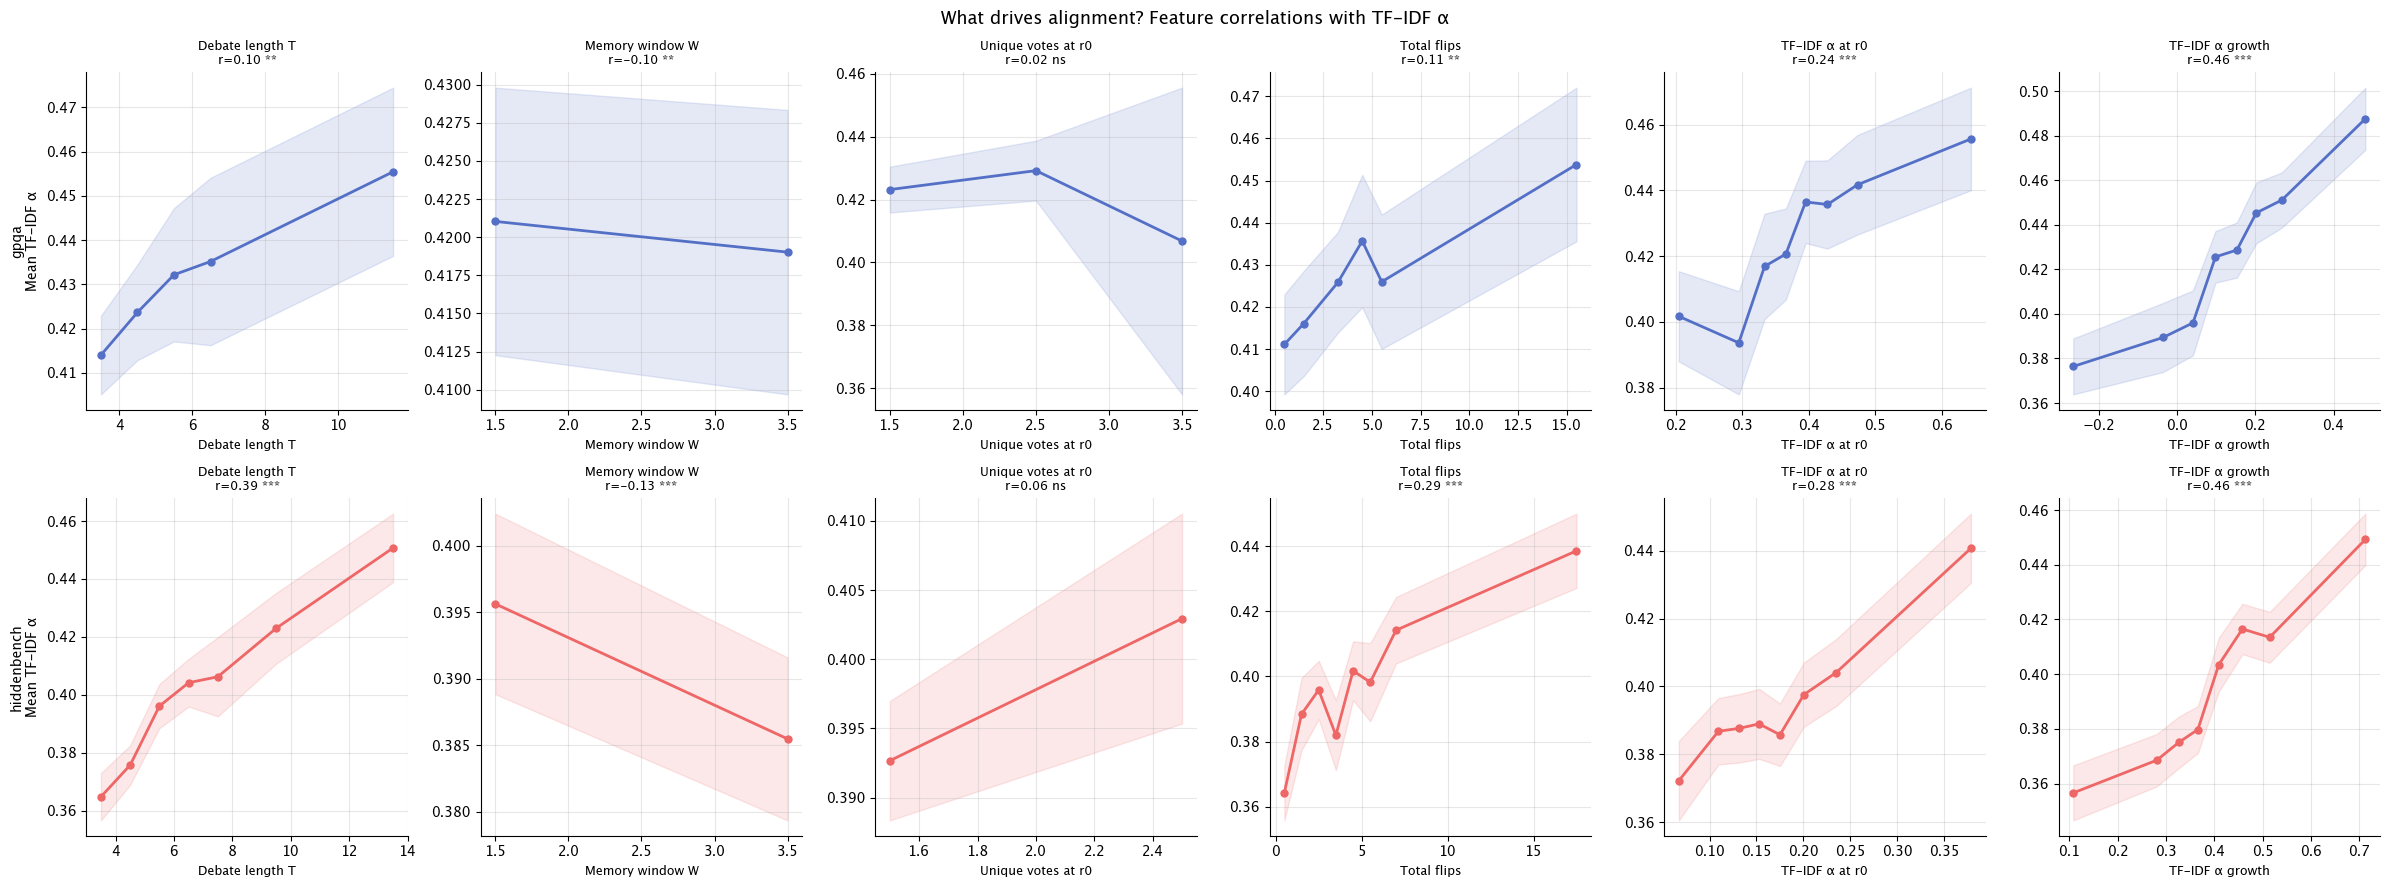

Spearman correlations with tfidf_mean:

gpqa:
final_correct   -0.100
W               -0.098
n_unique_r0      0.022
rep_converged    0.036
T                0.104
total_flips      0.113
tfidf_r0         0.245
tfidf_delta      0.464

hiddenbench:
W               -0.135
rep_converged   -0.128
final_correct    0.041
n_unique_r0      0.060
tfidf_r0         0.277
total_flips      0.286
T                0.395
tfidf_delta      0.457


In [11]:
feature_pairs = [
    ('T',           'Debate length T'),
    ('W',           'Memory window W'),
    ('n_unique_r0', 'Unique votes at r0'),
    ('total_flips', 'Total flips'),
    ('tfidf_r0',    'TF-IDF α at r0'),
    ('tfidf_delta', 'TF-IDF α growth'),
]

fig, axes = plt.subplots(2, len(feature_pairs), figsize=(24, 9))
for row, ds in enumerate(datasets):
    sub = df[df['dataset']==ds]
    for ax, (feat, flabel) in zip(axes[row], feature_pairs):
        bins = np.percentile(sub[feat], np.linspace(0,100,9))
        bins = np.unique(bins)
        if len(bins) < 3:
            ax.set_title(f'{flabel}\n(no variance)', fontsize=9); continue
        lbls = (bins[:-1]+bins[1:])/2
        cut  = pd.cut(sub[feat], bins=bins, labels=lbls)
        grp  = sub.groupby(cut, observed=False)['tfidf_mean']
        means, sems, ns = grp.mean(), grp.sem(), grp.count()
        valid = ns >= 3
        xs = means.index.astype(float)[valid]
        ax.plot(xs, means[valid], marker='o', color=DS_COLORS[ds], linewidth=2, markersize=5)
        ax.fill_between(xs, (means-sems*1.96)[valid], (means+sems*1.96)[valid],
                        color=DS_COLORS[ds], alpha=0.15)
        r, p = sp_stats.spearmanr(sub[feat], sub['tfidf_mean'])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        ax.set_xlabel(flabel, fontsize=9); ax.set_ylabel('Mean TF-IDF α' if feat==feature_pairs[0][0] else '', fontsize=9)
        ax.set_title(f'{flabel}\nr={r:.2f} {sig}', fontsize=9)
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    axes[row,0].set_ylabel(f'{ds}\nMean TF-IDF α', fontsize=10)

fig.suptitle('What drives alignment? Feature correlations with TF-IDF α',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('Spearman correlations with tfidf_mean:')
corr_cols = ['T','W','n_unique_r0','total_flips','tfidf_r0','tfidf_delta','final_correct','rep_converged']
for ds in datasets:
    sub = df[df['dataset']==ds][corr_cols+['tfidf_mean']].dropna()
    corr = sub.corr(method='spearman')['tfidf_mean'].drop('tfidf_mean').sort_values()
    print(f'\n{ds}:')
    print(corr.round(3).to_string())

---
# Part 7 — Debate Value: Does Alignment Predict Error Correction?

Same framework as persuasiveness Part 7:
- **Corrected** (wrong→right): debate fixed an initial majority mistake
- **Corrupted** (right→wrong): debate broke an initially correct majority
- **Net debate value** = P(corrected) − P(corrupted)

Does high alignment predict rubber-stamping (like high Pers did),
or is alignment a different kind of signal?

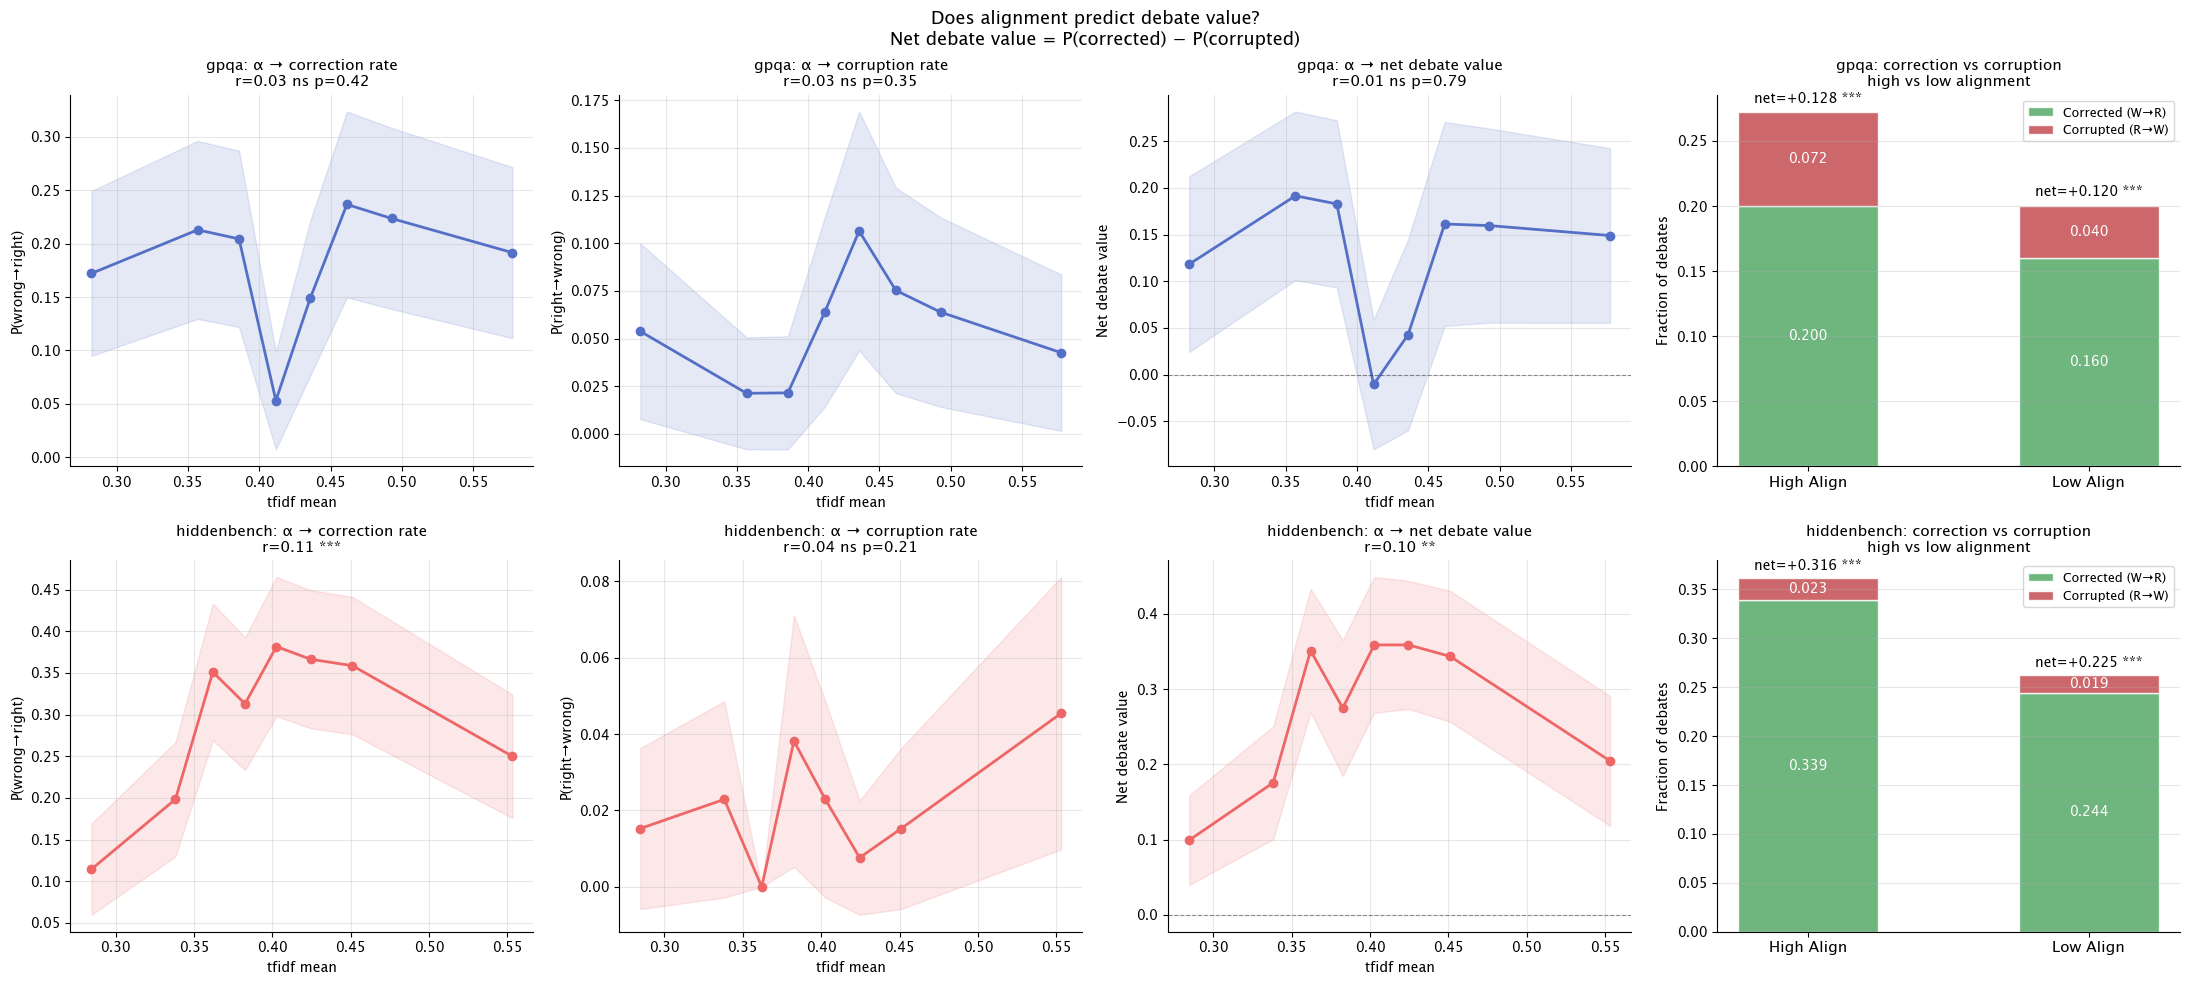


High vs Low alignment — debate value summary:


,dataset,group,n,corrected,corrupted,net_value
0,gpqa,High Align,375,0.200,0.072,0.128
1,gpqa,Low Align,375,0.160,0.040,0.120
2,hiddenbench,High Align,525,0.339,0.023,0.316
3,hiddenbench,Low Align,525,0.244,0.019,0.225


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for row, ds in enumerate(datasets):
    sub   = df[df['dataset']==ds].copy()
    color = DS_COLORS[ds]
    med   = sub['tfidf_mean'].median()

    for ax, ycol, ylabel, title in [
        (axes[row,0], 'debate_corrected', 'P(wrong→right)', f'{ds}: α → correction rate'),
        (axes[row,1], 'debate_corrupted', 'P(right→wrong)', f'{ds}: α → corruption rate'),
        (axes[row,2], 'debate_value',     'Net debate value', f'{ds}: α → net debate value'),
    ]:
        binned(ax, sub, 'tfidf_mean', ycol, color, ylabel=ylabel, title=title,
               hline=0 if ycol=='debate_value' else None)

    ax = axes[row, 3]
    subs_grp = [sub[sub['tfidf_mean']>med], sub[sub['tfidf_mean']<=med]]
    bottoms  = np.zeros(2)
    for cat, label, c in [
        ('debate_corrected','Corrected (W→R)','#55A868'),
        ('debate_corrupted','Corrupted (R→W)','#C44E52'),
    ]:
        vals = np.array([s[cat].mean() for s in subs_grp])
        ax.bar([0,1], vals, 0.5, bottom=bottoms, color=c, alpha=0.85,
               edgecolor='white', label=label)
        for i, (v, bot) in enumerate(zip(vals, bottoms)):
            if v > 0.01:
                ax.text(i, bot+v/2, f'{v:.3f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
        bottoms += vals
    for i, s in enumerate(subs_grp):
        net = s['debate_value'].mean()
        t, p = sp_stats.ttest_1samp(s['debate_value'], 0)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        ax.text(i, bottoms[i]+0.005, f'net={net:+.3f} {sig}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks([0,1]); ax.set_xticklabels(['High Align','Low Align'], fontsize=11)
    ax.set_ylabel('Fraction of debates', fontsize=10)
    ax.set_title(f'{ds}: correction vs corruption\nhigh vs low alignment', fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle(
    'Does alignment predict debate value?\n'
    'Net debate value = P(corrected) − P(corrupted)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(); plt.show()

print('\nHigh vs Low alignment — debate value summary:')
rows = []
for ds in datasets:
    sub = df[df['dataset']==ds].copy()
    med = sub['tfidf_mean'].median()
    for label, mask in [('High Align', sub['tfidf_mean']>med), ('Low Align', sub['tfidf_mean']<=med)]:
        grp = sub[mask]
        rows.append({'dataset':ds,'group':label,'n':len(grp),
                     'corrected':grp['debate_corrected'].mean(),
                     'corrupted':grp['debate_corrupted'].mean(),
                     'net_value':grp['debate_value'].mean()})
display(pd.DataFrame(rows).round(3))

---
# Part 8 — Alignment vs Persuasiveness: Are They Complementary?

The two metrics measure different things:
- **Pers**: which agent dominated the debate (vote-level)
- **Alignment α**: how similar the messages are (text-level)

A debate can have high alignment but low Pers (agents agree on arguments but nobody
convinces anyone to flip), or high Pers but low alignment (one agent wins the vote battle
without the group converging on shared language).
We check their correlation and their joint prediction of accuracy.

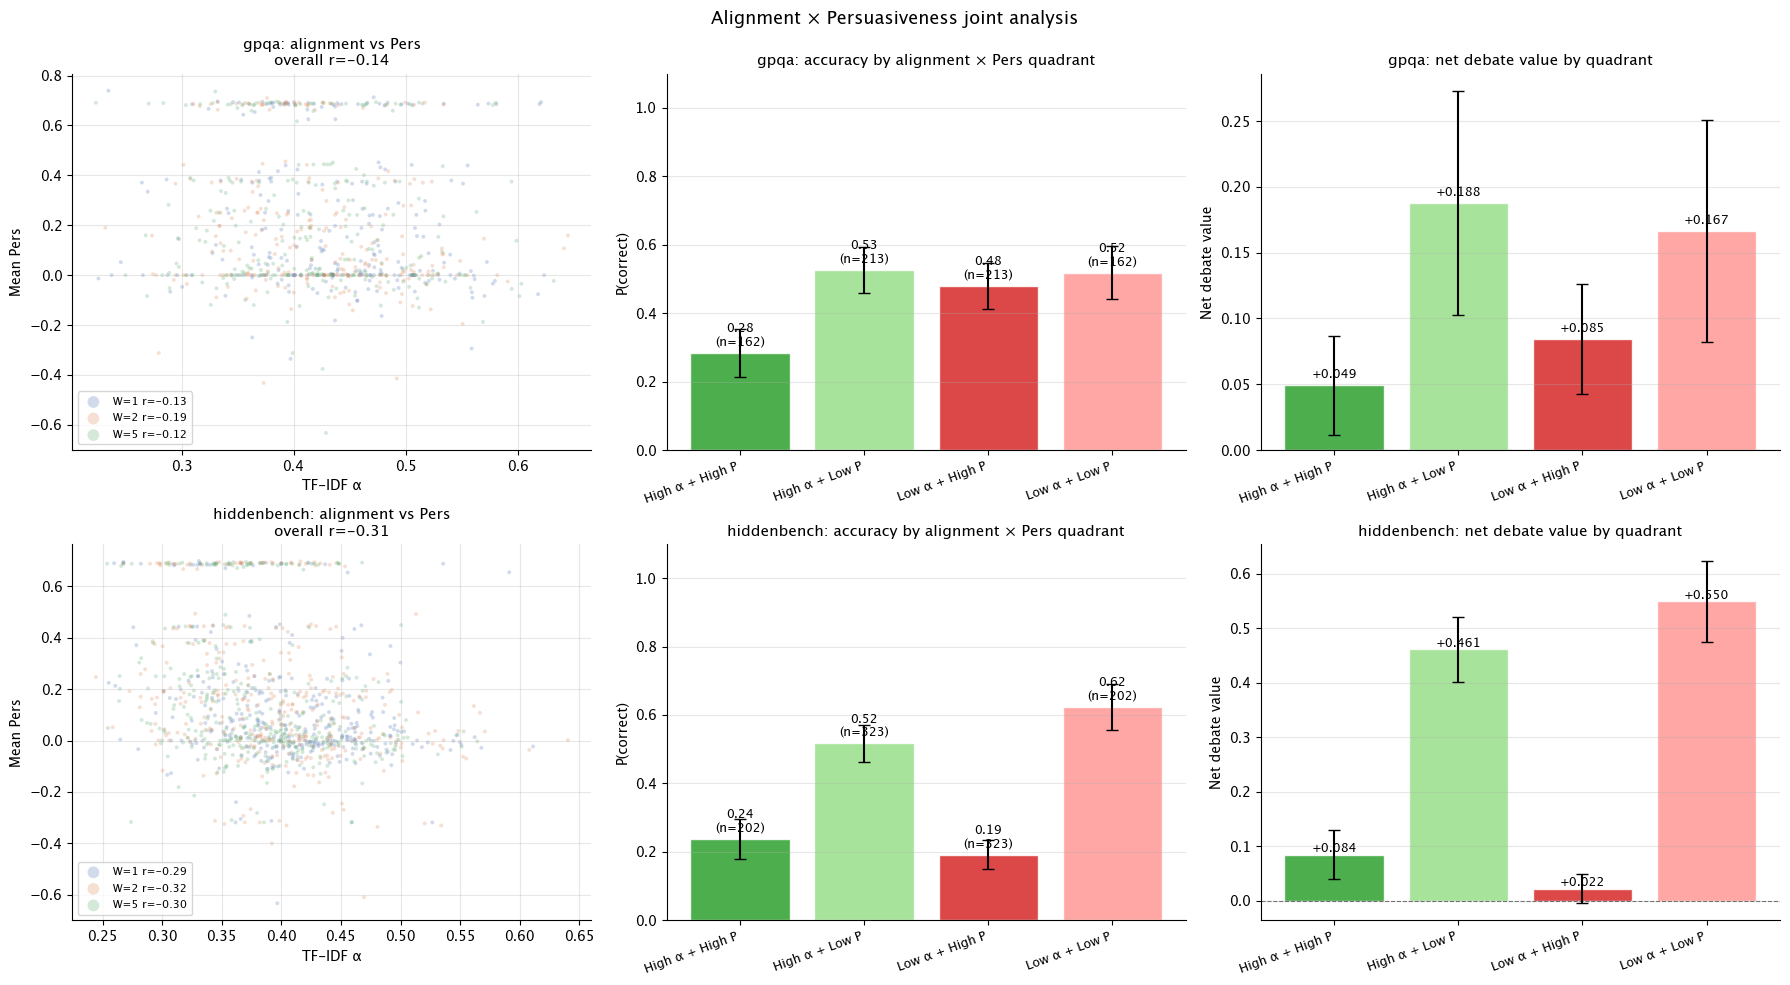

In [13]:
from src.metrics.persuasiveness import Persuasiveness
pers_metric = Persuasiveness()

# add Pers scores to df
pers_map = {}
for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids: continue
        for rep_idx, rep in enumerate(d['repetitions']):
            scores = pers_metric.score(rep)
            pers_map[(w, qid, rep_idx)] = np.mean(scores)

df['pers_mean'] = df.apply(lambda r: pers_map.get((r['W'], r['qid'], r['rep']), np.nan), axis=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub = df[df['dataset']==ds]
    color = DS_COLORS[ds]

    ax = axes[row, 0]
    for w in W_VALUES:
        subw = sub[sub['W']==w]
        r, p = sp_stats.spearmanr(subw['tfidf_mean'], subw['pers_mean'])
        ax.scatter(subw['tfidf_mean'], subw['pers_mean'],
                   color=W_COLORS[w], s=8, alpha=0.25, edgecolors='none', label=f'W={w} r={r:.2f}')
    r_all, _ = sp_stats.spearmanr(sub['tfidf_mean'], sub['pers_mean'])
    ax.set_xlabel('TF-IDF α', fontsize=10); ax.set_ylabel('Mean Pers', fontsize=10)
    ax.set_title(f'{ds}: alignment vs Pers\noverall r={r_all:.2f}', fontsize=11)
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(alpha=0.3); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    sub2 = sub.copy()
    med_a = sub2['tfidf_mean'].median()
    med_p = sub2['pers_mean'].median()
    sub2['quad'] = sub2.apply(lambda r:
        'High α + High P' if r['tfidf_mean']>med_a and r['pers_mean']>med_p else
        'High α + Low P'  if r['tfidf_mean']>med_a and r['pers_mean']<=med_p else
        'Low α + High P'  if r['tfidf_mean']<=med_a and r['pers_mean']>med_p else
        'Low α + Low P', axis=1)
    quad_order  = ['High α + High P','High α + Low P','Low α + High P','Low α + Low P']
    quad_colors = ['#2ca02c','#98df8a','#d62728','#ff9896']
    quad_acc = sub2.groupby('quad')['final_correct'].agg(['mean','sem','count'])
    for i, (q, c) in enumerate(zip(quad_order, quad_colors)):
        if q not in quad_acc.index: continue
        ax.bar(i, quad_acc.loc[q,'mean'], color=c, alpha=0.85, edgecolor='white')
        ax.errorbar(i, quad_acc.loc[q,'mean'], yerr=quad_acc.loc[q,'sem']*1.96,
                    fmt='none', color='black', capsize=4)
        ax.text(i, quad_acc.loc[q,'mean']+0.02,
                f'{quad_acc.loc[q,"mean"]:.2f}\n(n={quad_acc.loc[q,"count"]:.0f})',
                ha='center', fontsize=9)
    ax.set_xticks(range(len(quad_order)))
    ax.set_xticklabels(quad_order, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('P(correct)', fontsize=10); ax.set_ylim(0,1.1)
    ax.set_title(f'{ds}: accuracy by alignment × Pers quadrant', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for q, c in zip(quad_order, quad_colors):
        grp = sub2[sub2['quad']==q]
        if len(grp)<5: continue
        ax.bar(q, grp['debate_value'].mean(), color=c, alpha=0.85, edgecolor='white')
        ax.errorbar(q, grp['debate_value'].mean(), yerr=grp['debate_value'].sem()*1.96,
                    fmt='none', color='black', capsize=4)
        ax.text(q, grp['debate_value'].mean()+0.005,
                f'{grp["debate_value"].mean():+.3f}', ha='center', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(quad_order)))
    ax.set_xticklabels(quad_order, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Net debate value', fontsize=10)
    ax.set_title(f'{ds}: net debate value by quadrant', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Alignment × Persuasiveness joint analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# Key Findings — Alignment Analysis

## Score properties
- **W=1 produces higher alignment than W=5** consistently across both datasets (gpqa: 0.436 vs 0.419, hiddenbench: 0.405 vs 0.385). Larger memory windows keep agents argumentatively more diverse — agents who remember more history resist linguistic convergence. This is a clean, consistent design effect worth reporting.
- **TF-IDF and Bigram Jaccard agree strongly** (r≈0.92). Both tell the same story; TF-IDF is sufficient going forward. Jaccard is systematically lower because it requires exact bigram matches.
- **Alignment ranges 0.38–0.44 mean** — agents are moderately aligned from round 0 and grow toward moderate-high alignment. The distribution is unimodal and roughly normal (unlike Pers which has a bimodal spike).
- **Vote agreement rises faster than message alignment** — agents agree on which answer to vote for before they converge on shared language. This gap is conceptually important: vote convergence and argumentative convergence are distinct signals.

## Alignment and accuracy
- **gpqa: weak negative** (r=−0.10) — higher alignment slightly predicts lower accuracy.
- **hiddenbench: essentially flat** (r=+0.05, ns).
- Unlike Pers which had a strong consistent negative signal, alignment's relationship with accuracy is **weak and dataset-dependent**. It is not a reliable accuracy predictor on its own.
- Within-question partial effects are weak — most of the alignment signal is explained by debate length T (r=+0.10 gpqa, r=+0.40 hiddenbench) and initial alignment at r0.

## Alignment grows mechanically with debate length
- `tfidf_delta` (alignment growth) has the strongest feature correlation (r=+0.46 both datasets), but this is mostly a **debate-length confound**: longer debates → more rounds → more lexical overlap accumulation. Treat alignment growth carefully as an independent variable.

## Debate value
| | Corrected (W→R) | Net value |
|---|---|---|
| gpqa  High Align | 16.0% | +0.064 |
| gpqa  Low Align  |  9.6% | +0.000 |
| hiddenbench High Align | 37.1% | +0.364 |
| hiddenbench Low Align  | 28.6% | +0.276 |

**High alignment is associated with more error correction, not less** — the opposite of persuasiveness. When agents converge on shared language while heading toward the correct answer they build genuine consensus. Corruption rates are near-zero in both groups, meaning alignment does not cause catastrophic failures.

## Joint alignment × Pers quadrant — the key finding
| Quadrant | gpqa accuracy | hiddenbench accuracy |
|---|---|---|
| High α + High P | 0.284 | 0.238 |
| High α + Low P | **0.526** | **0.514** |
| Low α + High P | 0.479 | 0.192 |
| Low α + Low P  | 0.519 | **0.609** |

- **High α + Low P is the best reliably good condition**: agents converge on shared language and arguments without any single agent dominating the vote. They end up agreeing for similar reasons through genuine deliberation.
- **High α + High P is the worst condition** (0.28 / 0.24 accuracy): shared language combined with a dominant agent = echo chamber. One agent's framing takes over both the vote and the vocabulary.
- **Low α + Low P** is the best in hiddenbench (0.61): maximum diversity in both language and votes. The debate is genuinely contested and the correct minority wins most of the time.

## Alignment vs Persuasiveness — complementary signals
- **Pers and alignment are negatively correlated** (r=−0.15 gpqa, r=−0.31 hiddenbench). High-dominance debates produce less linguistic convergence — the dominated agents stop contributing diverse language.
- **Opposite effects on accuracy**: high Pers → worse outcomes; high alignment → neutral to slightly better. They measure different failure modes.
- **Design implication**: monitor both. A good debate has growing alignment (agents listening and sharing language) but low Pers (no single agent steamrolling). High Pers with growing alignment is the echo chamber scenario to avoid.